# Nonlinear groundwater equation — small explicit examples

We consider the pressure-head equation

$$c_S\,\partial_t u-\nabla\cdot\left[\lambda(u)\,\Lambda(\nabla u+\mathbf e_z)\right]=0.$$

Here $\Lambda$ is a constant saturated conductivity and $\lambda(u)$ is the nonlinear relative conductivity. The examples deliberately keep every calculation in its notebook cell; there are no helper functions hidden elsewhere. The vertical coordinate $z$ points upward, hence $\mathbf e_z=(0,1)$.

In [1]:
using Symbolics
using CairoMakie
using LinearAlgebra

## Load flexOPT

The cell below works when Jupyter starts either in the repository root or in `notebooks/`. Set `ENV["FLEXOPT_ROOT"]` only when the notebook is launched elsewhere. `batchGPU.jl` selects CUDA, Metal, or the CPU automatically.

In [2]:
import Pkg

flexopt_root = if haskey(ENV, "FLEXOPT_ROOT")
    abspath(expanduser(ENV["FLEXOPT_ROOT"]))
elseif isfile(joinpath(pwd(), "Project.toml"))
    abspath(pwd())
else
    abspath(joinpath(pwd(), ".."))
end

isfile(joinpath(flexopt_root, "Project.toml")) ||
    error("flexOPT not found; set ENV[\"FLEXOPT_ROOT\"]")

Pkg.activate(flexopt_root)

include(joinpath(flexopt_root, "src", "batchFiles", "batchGPU.jl"))
include(joinpath(flexopt_root, "src", "commonBatchs.jl"))
include(joinpath(flexopt_root, "src", "planet1D.jl"))
planet1D.configure_input!()
include(joinpath(flexopt_root, "src", "GeoPoints.jl"))
include(joinpath(flexopt_root, "src", "flexOPT.jl"))

using .commonBatchs, .planet1D, .GeoPoints, .flexOPT

@show VERSION Base.active_project() typeof(backend)

  Activating 

→ Using CPU backend (no GPU detected)


project at `~/Documents/Github/flexOPT`


Selected backend type: CPU
VERSION = v"1.12.6"
Base.active_project() = "/Users/nobuaki/Documents/Github/flexOPT/Project.toml"
typeof(backend) = CPU


CPU

## 1. Two readable choices for $\lambda(u)$

Set $q=c_1u$. The power law below is exactly zero for $u\leq0$, reaches one at $u=1/c_1$, and stays one above that point:

$$\lambda_{\rm power}(u)=\begin{cases}0&q\leq0,\\q^\gamma&0<q<1,\\1&q\geq1.\end{cases}$$

The quintic smoothstep has zero first derivative at both joins. Raising it to $\gamma$ changes the shape without changing its range.

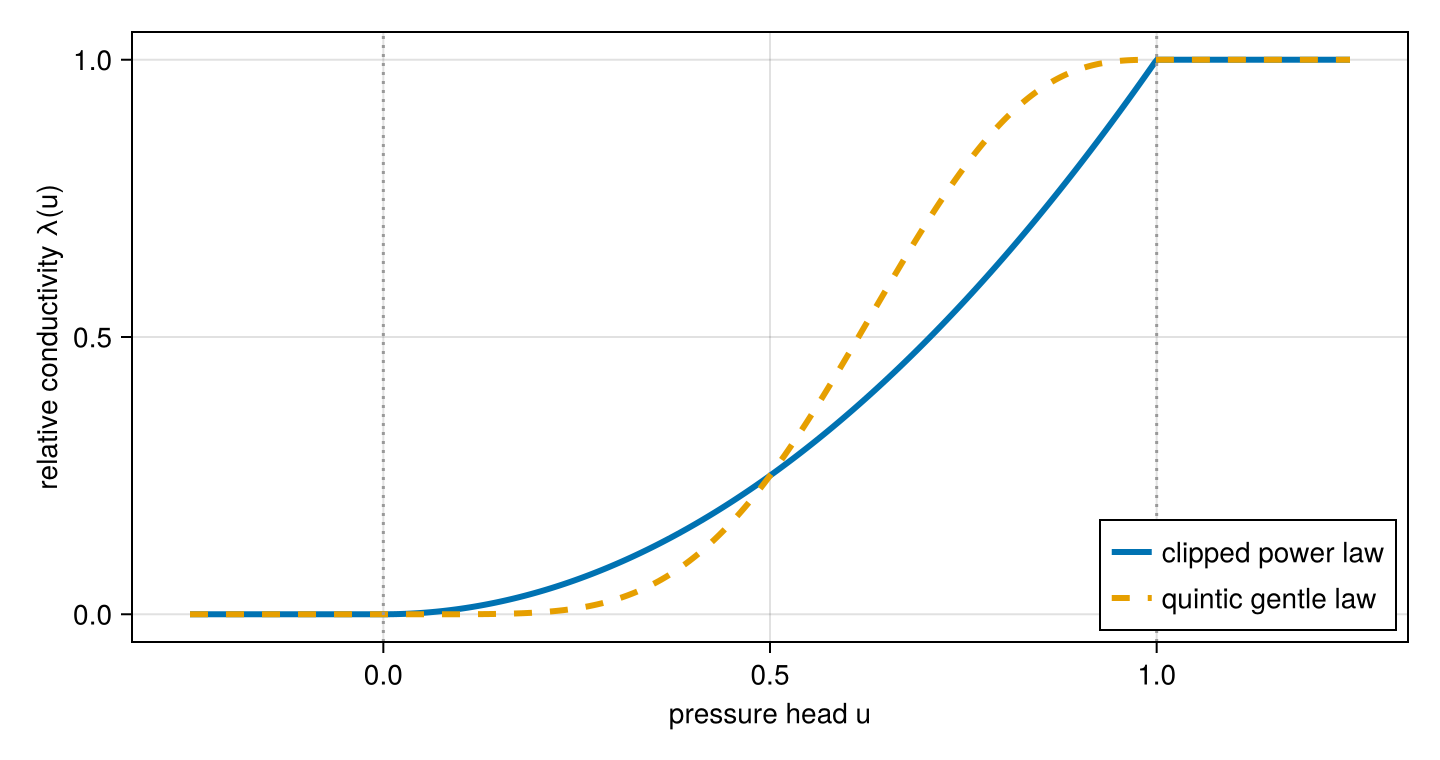

In [3]:
c₁ = 1.0
γ = 2.0
cₛ = 1.e-3
u_plot = range(-0.25, 1.25; length=500)

q_plot = clamp.(c₁ .* u_plot, 0.0, 1.0)
λ_power = q_plot .^ γ
λ_gentle = (q_plot .^ 3 .* (10 .- 15 .* q_plot .+ 6 .* q_plot .^ 2)) .^ γ

fig_λ = Figure(size=(720, 380))
ax_λ = Axis(fig_λ[1, 1]; xlabel="pressure head u", ylabel="relative conductivity λ(u)")
lines!(ax_λ, u_plot, λ_power; linewidth=3, label="clipped power law")
lines!(ax_λ, u_plot, λ_gentle; linewidth=3, linestyle=:dash, label="quintic gentle law")
vlines!(ax_λ, [0.0, 1 / c₁]; color=:gray60, linestyle=:dot)
axislegend(ax_λ; position=:rb)
fig_λ

The normalization is $(c_1u)^\gamma$, not $c_1u^\gamma$: the former equals one at $u=1/c_1$. For Newton or gradient-based solvers, the quintic choice is usually friendlier than a sharp Heaviside.

## 2. Write the 2-D equation without making $\lambda$ an independent field

In the $(x,z)$ plane, $\nabla u+\mathbf e_z=(u_x,u_z+1)$. For scalar constant $\Lambda$, define the two components inside the divergence explicitly. `λᵤ` depends on `u(x,z,t)`; it is not declared as `λ(x,z,t)`.

In [4]:
@variables x z t
@variables u(x, z, t) cₛ Λ c₁_symbolic γ_symbolic

∂x = Differential(x)
∂z = Differential(z)
∂t = Differential(t)

qᵤ = c₁_symbolic * u
sᵤ = qᵤ^3 * (10 - 15qᵤ + 6qᵤ^2)
λᵤ = ifelse(qᵤ <= 0, 0, ifelse(qᵤ < 1, sᵤ^γ_symbolic, 1))

flux_x = λᵤ * Λ * ∂x(u)
flux_z = λᵤ * Λ * (∂z(u) + 1)
groundwater_residual = cₛ * ∂t(u) - ∂x(flux_x) - ∂z(flux_z)
groundwater_equation = groundwater_residual ~ 0

-Differential(x)(Differential(x)(u(x, z, t))*ifelse((c₁_symbolic*u(x, z, t)) <= 0, 0, ifelse((c₁_symbolic*u(x, z, t)) < 1, ((10 - 15c₁_symbolic*u(x, z, t) + (6//1)*(c₁_symbolic^2)*(u(x, z, t)^2))*(c₁_symbolic^3)*(u(x, z, t)^3))^γ_symbolic, 1))*Λ) - Differential(z)(ifelse((c₁_symbolic*u(x, z, t)) <= 0, 0, ifelse((c₁_symbolic*u(x, z, t)) < 1, ((10 - 15c₁_symbolic*u(x, z, t) + (6//1)*(c₁_symbolic^2)*(u(x, z, t)^2))*(c₁_symbolic^3)*(u(x, z, t)^3))^γ_symbolic, 1))*(1 + Differential(z)(u(x, z, t)))*Λ) + cₛ*Differential(t)(u(x, z, t)) ~ 0

For a constant anisotropic tensor $\boldsymbol\Lambda=[\Lambda_{ij}]$, only the flux cell changes:

```julia
flux_x = λᵤ * (Λxx * ∂x(u) + Λxz * (∂z(u) + 1))
flux_z = λᵤ * (Λzx * ∂x(u) + Λzz * (∂z(u) + 1))
```

The Darcy flux used in the Neumann condition has the opposite sign: $\mathbf Q=-(\texttt{flux_x},\texttt{flux_z})$. Thus $\mathbf Q\cdot\mathbf n=g_2$.

## 3. Small vertical-column experiment

This finite-volume-style example solves

$$c_Su_t=\partial_z\{\lambda(u)\Lambda(u_z+1)\}$$

on $0\le z\le H$. We impose hydrostatic Dirichlet heads $u=z_0-z$ at the bottom and top. The initial condition is perturbed in the interior. Face fluxes are computed first, then their divergence updates the cell values.

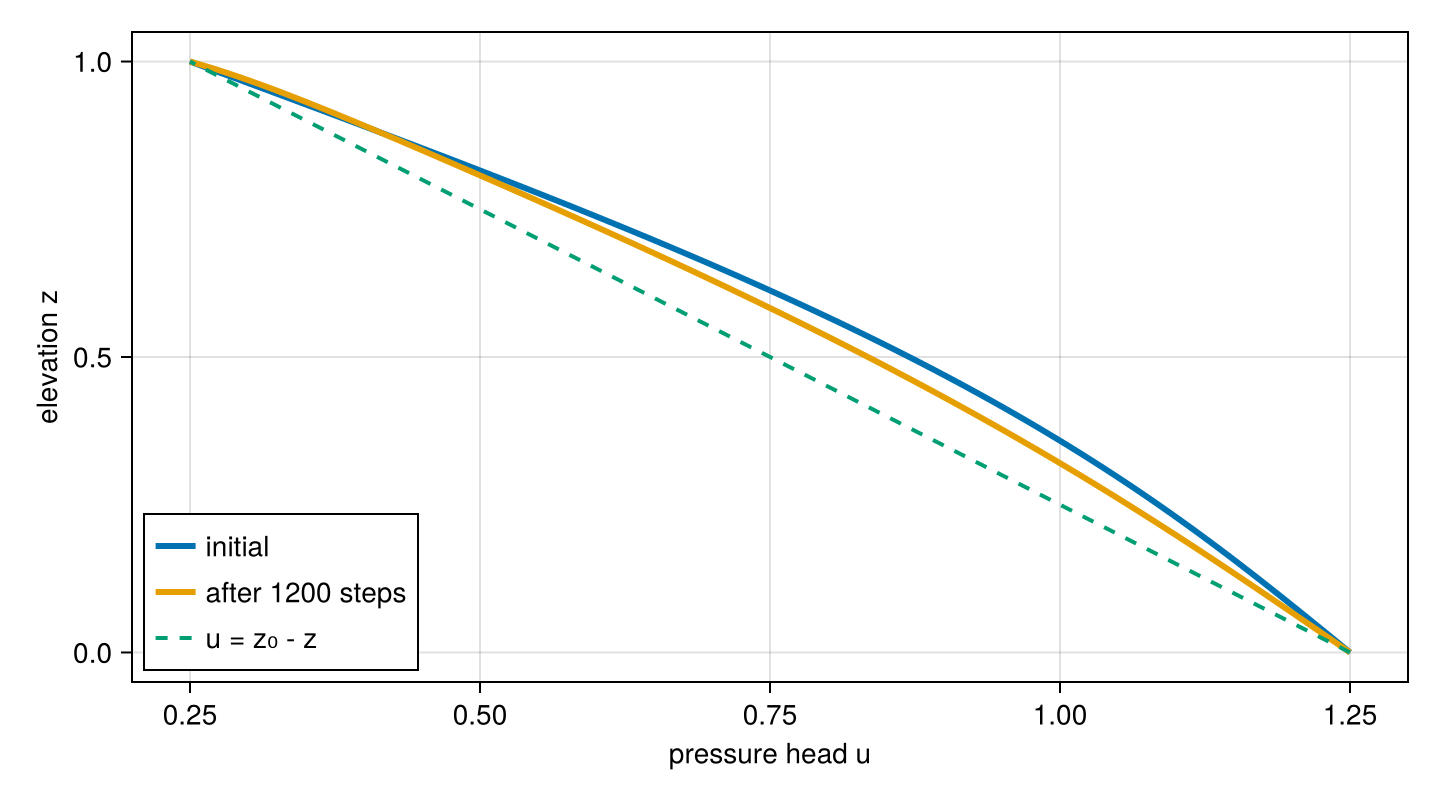

In [5]:
H = 1.0
Nz = 81
z_grid = range(0.0, H; length=Nz)
Δz = step(z_grid)

cₛ_num = 1.0
Λ_num = 0.05
c₁_num = 2.0
γ_num = 2.0
z₀ = 1.25                         # keeps the exact hydrostatic head positive

u_hydrostatic = z₀ .- z_grid
u_num = u_hydrostatic .+ 0.12 .* sin.(π .* z_grid ./ H)
u_initial = copy(u_num)

Δt = 0.20 * cₛ_num * Δz^2 / Λ_num
Nt = 1200

for it in 1:Nt
    q_nodes = clamp.(c₁_num .* u_num, 0.0, 1.0)
    λ_nodes = (q_nodes .^ 3 .* (10 .- 15 .* q_nodes .+ 6 .* q_nodes .^ 2)) .^ γ_num

    λ_faces = 0.5 .* (λ_nodes[1:end-1] .+ λ_nodes[2:end])
    flux_faces = Λ_num .* λ_faces .* ((u_num[2:end] .- u_num[1:end-1]) ./ Δz .+ 1.0)

    u_num[2:end-1] .+= (Δt / (cₛ_num * Δz)) .*
        (flux_faces[2:end] .- flux_faces[1:end-1])

    u_num[1] = z₀
    u_num[end] = z₀ - H
end

fig_column = Figure(size=(720, 400))
ax_column = Axis(fig_column[1, 1]; xlabel="pressure head u", ylabel="elevation z")
lines!(ax_column, u_initial, z_grid; linewidth=3, label="initial")
lines!(ax_column, u_num, z_grid; linewidth=3, label="after $(Nt) steps")
lines!(ax_column, u_hydrostatic, z_grid; linewidth=2, linestyle=:dash, label="u = z₀ - z")
axislegend(ax_column; position=:lb)
fig_column

### Hydrostatic/no-flow check

For $u=z_0-z$, one has $u_z+1=0$. Consequently the Darcy flux is zero regardless of the nonlinear value of $\lambda(u)$. This is a useful sign check before introducing rainfall or mixed boundaries.

In [6]:
q_hydro = clamp.(c₁_num .* u_hydrostatic, 0.0, 1.0)
λ_hydro = (q_hydro .^ 3 .* (10 .- 15 .* q_hydro .+ 6 .* q_hydro .^ 2)) .^ γ_num
λ_hydro_faces = 0.5 .* (λ_hydro[1:end-1] .+ λ_hydro[2:end])
darcy_flux_hydro = -Λ_num .* λ_hydro_faces .*
    ((u_hydrostatic[2:end] .- u_hydrostatic[1:end-1]) ./ Δz .+ 1.0)

maximum(abs, darcy_flux_hydro)

2.7755575615629308e-18

## Boundary values for the 2-D test case

For grid elevations `z_grid`, the boundary data from the paper can be written directly as:

```julia
u_left  = max.(z₀_left .- z_grid, 0.0) # Dirichlet
u_right = z₀_right .- z_grid           # Dirichlet
u_top   = 0.0                           # Dirichlet
Qn_left = 0.0                           # Neumann Q⋅n
Qn_right = 0.0
Qn_bottom = 0.0
Qn_top = R
```

A boundary segment must receive either Dirichlet or Neumann data, not both. At corner nodes, choose an explicit precedence rule; in a simple strong-Dirichlet discretization it is natural to let a Dirichlet side override an adjacent Neumann face. Positive $R$ follows the paper's outward-normal convention $\mathbf Q\cdot\mathbf n=R$; check whether the intended physical rainfall is inward, since that would use a negative outward flux.

## 4. OPT numerical operators

The symbolic equation is nonlinear, but an OPT numerical operator is linear once its coefficients are fixed. We therefore use a Picard step:

$$\lambda(h_p)\;\longrightarrow\;\lambda(h_p^k),$$

where `hₚᵏ(x,z)` is the spatial head from the preceding nonlinear iteration. In `famousEquations.jl`, `hₚ` remains the solved field and `hₚᵏ` is the fifth numerical model. After solving for a new head, replace that fifth model and assemble again.

In [7]:
famousEquationType = "2Dgoundwater"
Δ = (0.10, 0.10, 1.0e-5)     # Δx, Δz, Δt; small for the diffusive scale Λ/cₛ
orderBtime = 1
orderBspace = 1
pointsInSpace = 3
pointsInTime = 3
supplementaryOrder = 2

fieldItpl = (
    ptsSpace=1, ptsTime=1, offsetSpace=1, offsetTime=1,
    YorderBspace=-1, YorderBtime=1,
)
materItpl = fieldItpl

groundwaterRecipeParameters = Dict{String,Any}(
    "famousEquationType" => famousEquationType,
    "Δ" => Δ,
    "orderBtime" => orderBtime,
    "orderBspace" => orderBspace,
    "pointsInSpace" => pointsInSpace,
    "pointsInTime" => pointsInTime,
    "supplementaryOrder" => supplementaryOrder,
    "fieldItpl" => fieldItpl,
    "materItpl" => materItpl,
)

groundwaterRecipe = makeOPTsemiSymbolic(groundwaterRecipeParameters)
groundwaterEquation, groundwaterForcing = famousEquations(famousEquationType)

@show groundwaterEquation.fields groundwaterEquation.vars
@show groundwaterRecipe["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching

(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 1)
(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 2)
(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 3)
(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 4)
(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 5)
(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 1)
(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 2)
(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 3)
(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 4)
(vars, iVars) = ((cₛ, Λ, c₁, γ, hₚᵏ(x, z)), 5)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = ava

true

The order of `groundwaterModels` must exactly match `vars = (cₛ, Λ, c₁, γ, hₚᵏ)`. The first four entries are scalars because they were declared constant. Only `hₚᵏ(x,z)` is a 2-D array. Do not replace the scalar constants by constant matrices: their declared symbolic dimension is zero.

In [8]:
NxOPT = 16
NzOPT = 12
xOPT = range(0.0; step=Δ[1], length=NxOPT)
zOPT = range(0.0; step=Δ[2], length=NzOPT)

cₛOPT = 1.0e-3
ΛOPT = 0.05
c₁OPT = 1.0
γOPT = 2.0
z₀OPT = 1.25

# Initial Picard state hₚ⁰. Array axes follow (x,z).
hₚᵏOPT = [max(z₀OPT - z, 0.0) for x in xOPT, z in zOPT]

groundwaterModels = Any[cₛOPT, ΛOPT, c₁OPT, γOPT, hₚᵏOPT]
timeMarching = groundwaterRecipe["recette"].numbersOfTheSystem.
    numbersOfTheSystemL.timeMarching
groundwaterModelPoints = getModelPoints(hₚᵏOPT, pointsInTime, timeMarching)

groundwaterModelFamily = (
    models=groundwaterModels,
    modelPoints=groundwaterModelPoints,
    Δ=Δ,
    modelName="groundwater_picard_k0",
)

@show size(hₚᵏOPT) groundwaterModelPoints

size(hₚᵏOPT) = (16, 12)
groundwaterModelPoints = (16, 12, 4)


(16, 12, 4)

In [9]:
groundwaterNumerical = numericalOperatorConstruction(Dict{String,Any}(
    "optRec" => groundwaterRecipe,
    "modelFam" => groundwaterModelFamily,
    "absorbingBoundaries" => nothing,
    "maskedRegionInSpace" => nothing,
    "representation" => "matrixfree",
))

groundwaterNumOps = groundwaterNumerical["numOperators"]

@show typeof(groundwaterNumOps.numericalOperators.left)
@show typeof(groundwaterNumOps.numericalOperators.right)
groundwaterNumOps

typeof(groundwaterNumOps.numericalOperators.left) = Main.flexOPT.MatrixFreeNumericalOperator{Float64}
typeof(groundwaterNumOps.numericalOperators.right) = Main.flexOPT.MatrixFreeNumericalOperator{Float64}


(costfunctions = Main.flexOPT.MatrixFreeNumericalOperator{Float64}(Main.flexOPT.CouplingTable{Float64}(Int32[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  192, 192, 192, 192, 192, 192, 192, 192, 192, 192], Int32[1, 4, 49, 52, 2, 5, 50, 53, 3, 6  …  1147, 1150, 1100, 1103, 1148, 1151, 1101, 1104, 1149, 1152], [2.604166869064734e-5, -5.729167765929377e-6, -5.729167765928309e-6, -1.4062494067309696e-6, 0.0007777778425947691, -0.00015555558796333772, -0.0001555555879633335, -3.888887268536015e-5, 2.9513891492271074e-5, -5.381945659594128e-6  …  -1.1574036142560473e-7, -1.1574082823959444e-6, -3.2407346343071936e-7, -3.2407420783795907e-6, -3.240742078066835e-6, -3.2407404500018845e-5, -1.1574234718584113e-8, -1.1574036127633524e-7, -1.1574036143286698e-7, -1.157408282399667e-6]), (192, 1152), "left-right", :cpu, :matrixfree, (left = (modelPoints = (16, 12, 4), wholeRegionPoints = (16, 12, 4), absorbingBoundaries = [0 0 0; 0 0 0], νWhole = CartesianIndex{2}[CartesianIndex(1, 1) CartesianIndex(1, 2) … Ca

### Next Picard iteration

Once the linear system produces `hₚ_new`, the nonlinear update is intentionally visible:

```julia
hₚᵏOPT .= hₚ_new
groundwaterModels[5] = hₚᵏOPT
groundwaterModelFamily = merge(groundwaterModelFamily,
    (models=groundwaterModels, modelName="groundwater_picard_next"))
groundwaterNumerical = numericalOperatorConstruction(Dict{String,Any}(
    "optRec" => groundwaterRecipe,
    "modelFam" => groundwaterModelFamily,
    "absorbingBoundaries" => nothing,
    "maskedRegionInSpace" => nothing,
    "representation" => "matrixfree",
))
```

Repeat until, for example, `maximum(abs, hₚ_new - hₚᵏ_previous) < tolerance`. Boundary rows and the actual time/Picard solve come next; this section deliberately establishes and verifies the nonlinear volume operators first.

In [10]:
ρ_water = 1000.0
g = 9.81

Lx = maximum(xOPT)
H = maximum(zOPT)

z₀_left = H
z₀_bottom = H

h_left = max.(z₀_left .- zOPT, 0.0)
h_bottom = fill(z₀_bottom, length(xOPT))
h_right = zeros(length(zOPT))
Qn_top = 0.0

0.0

In [13]:
hₚ_initial = [
    (1 - x / Lx) * max(z₀_left - z, 0.0)
    for x in xOPT, z in zOPT
]
hₚ_initial[1, :] .= h_left
hₚ_initial[:, 1] .= h_bottom
hₚ_initial[end, :] .= h_right
hₚ_initial[end, :] .= 0.0

12-element view(::Matrix{Float64}, 16, :) with eltype Float64:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

## 5. First 2-D video from `groundwaterNumOps`

This first movie uses the operator assembled above, hence $\lambda(h_p^0)$ stays frozen throughout the movie. It is a simple *frozen Picard* diagnostic. The left and bottom heads are fixed, the right side is drained with $h_p=0$, and the unmodified top rows retain the natural zero-flux condition. The right boundary is imposed last, so the lower-right corner belongs to the drain.

In [ ]:
using SparseArrays

preparedGroundwater = prepareLinearSystem(groundwaterNumOps)
@show preparedGroundwater.spaceShape preparedGroundwater.timePointsUsedForOneStep

preparedGroundwater.spaceShape == (NxOPT, NzOPT) ||
    error("unexpected groundwater operator shape $(preparedGroundwater.spaceShape)")

NknownTime = preparedGroundwater.timePointsUsedForOneStep - 1
knownHead = zeros(Float64, size(preparedGroundwater.known_lhs_template))
knownSource = zeros(Float64, size(preparedGroundwater.known_rhs_template))
newHead = zeros(Float64, preparedGroundwater.NpointsSpace, preparedGroundwater.NField)

# Initial state and all required past time levels.
hₚ_initial_video = copy(hₚ_initial)
for iknown in 1:NknownTime
    knownHead[:, 1, iknown] .= vec(hₚ_initial_video)
end

# Strong Dirichlet rows. LinearIndices follows Julia's (x,z) storage order.
linearGrid = LinearIndices((NxOPT, NzOPT))
leftRows = vec(linearGrid[1, :])
bottomRows = vec(linearGrid[:, 1])
rightRows = vec(linearGrid[end, :])
dirichletRows = unique(vcat(leftRows, bottomRows, rightRows))
dirichletHead = zeros(Float64, preparedGroundwater.NpointsSpace)
dirichletHead[leftRows] .= h_left
dirichletHead[bottomRows] .= h_bottom
dirichletHead[rightRows] .= h_right

Agroundwater = sparse(preparedGroundwater.A_template)
for row in dirichletRows
    Agroundwater[row, :] .= 0.0
    Agroundwater[row, row] = 1.0
end
dropzeros!(Agroundwater)
groundwaterFactor = lu(Agroundwater)

NtVideo = 60
storeEvery = 1
groundwaterFrames = Matrix{Float64}[copy(hₚ_initial_video)]
bgroundwater = copy(preparedGroundwater.b_template)

for it in 1:NtVideo
    knownInputs = vcat(vec(knownHead), vec(knownSource))
    preparedGroundwater.b_fun!(bgroundwater, knownInputs)
    bgroundwater[dirichletRows] .= dirichletHead[dirichletRows]

    newHead[:, 1] .= real.(groundwaterFactor \ bgroundwater)
    all(isfinite, newHead) || error("non-finite head at time step $it")

    if it % storeEvery == 0
        push!(groundwaterFrames, reshape(copy(newHead[:, 1]), NxOPT, NzOPT))
    end

    if NknownTime > 1
        knownHead[:, :, 1:end-1] .= knownHead[:, :, 2:end]
    end
    knownHead[:, :, end] .= newHead
end

@show length(groundwaterFrames) extrema(last(groundwaterFrames))

In [ ]:
CairoMakie.activate!()
groundwaterVideoPath = joinpath(flexopt_root, "data", "groundwater_head_frozen_picard.mp4")
mkpath(dirname(groundwaterVideoPath))

headObservable = Observable(groundwaterFrames[1])
figGroundwater = Figure(size=(900, 560))
axGroundwater = Axis(
    figGroundwater[1, 1];
    xlabel="x", ylabel="z",
    title="2-D groundwater — frozen λ(hₚ⁰)",
    aspect=DataAspect(),
)
headMap = heatmap!(
    axGroundwater, xOPT, zOPT, headObservable;
    colormap=:viridis, colorrange=(0.0, z₀OPT),
)
Colorbar(figGroundwater[1, 2], headMap; label="pressure head hₚ")

record(figGroundwater, groundwaterVideoPath, eachindex(groundwaterFrames); framerate=15) do iframe
    headObservable[] = groundwaterFrames[iframe]
    timeValue = (iframe - 1) * storeEvery * Δ[3]
    axGroundwater.title = "2-D groundwater — t = $(round(timeValue; digits=3))"
end

groundwaterVideoPath